In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [91]:
df = pd.read_csv('final_data.csv')

In [ ]:
def apply_local_timezone(df):
    """
    TRANSACTION_STATE를 기반으로 UTC 시간을 각 지역의 정확한 현지 시간으로 변환하는 함수
    """
    print("시간대 변환을 시작합니다. (데이터 크기에 따라 수초~수십초 소요될 수 있습니다)")
    
    # 1. State별 주요 Timezone 매핑 딕셔너리
    tz_mapping = {
        # Eastern Time (EST/EDT)
        'OH':'America/New_York', 'MI':'America/New_York', 'IN':'America/New_York', 'NC':'America/New_York', 
        'FL':'America/New_York', 'VA':'America/New_York', 'MA':'America/New_York', 'SC':'America/New_York', 
        'GA':'America/New_York', 'PA':'America/New_York', 'DE':'America/New_York', 'MD':'America/New_York', 
        'NY':'America/New_York', 'CT':'America/New_York', 'WV':'America/New_York', 'RI':'America/New_York', 
        'NJ':'America/New_York', 'DC':'America/New_York', 'ME':'America/New_York', 'VT':'America/New_York', 
        'NH':'America/New_York',
        
        # Central Time (CST/CDT)
        'MN':'America/Chicago', 'WI':'America/Chicago', 'TX':'America/Chicago', 'LA':'America/Chicago', 
        'IL':'America/Chicago', 'MS':'America/Chicago', 'TN':'America/Chicago', 'NE':'America/Chicago', 
        'MO':'America/Chicago', 'AL':'America/Chicago', 'ND':'America/Chicago', 'OK':'America/Chicago', 
        'IA':'America/Chicago', 'SD':'America/Chicago', 'AR':'America/Chicago', 'KS':'America/Chicago',
        
        # Mountain Time (MST/MDT)
        'CO':'America/Denver', 'UT':'America/Denver', 'NM':'America/Denver', 'ID':'America/Denver', 
        'MT':'America/Denver', 'WY':'America/Denver', 
        'AZ':'America/Phoenix', # 애리조나는 서머타임을 적용하지 않아 별도 분리
        
        # Pacific Time (PST/PDT)
        'CA':'America/Los_Angeles', 'NV':'America/Los_Angeles', 'WA':'America/Los_Angeles', 'OR':'America/Los_Angeles',
        
        # 기타 지역 및 해외 영토
        'AK':'America/Anchorage', 'HI':'Pacific/Honolulu', 
        'PR':'America/Puerto_Rico', 'VI':'America/Puerto_Rico', 'GU':'Pacific/Guam', 'MP':'Pacific/Guam', 'AS':'Pacific/Pago_Pago',
        
        # 군사 우편번호(AE, AP, AA) 등은 임의로 UTC나 동부시간으로 설정
        'AE':'UTC', 'AP':'UTC', 'AA':'America/New_York'
    }

    # 2. TRANSACTION_DATE를 Datetime 객체로 변환하고 기본값을 UTC로 명시
    if not pd.api.types.is_datetime64_any_dtype(df['TRANSACTION_DATE']):
        df['TRANSACTION_DATE'] = pd.to_datetime(df['TRANSACTION_DATE'])
    
    if df['TRANSACTION_DATE'].dt.tz is None:
        df['TRANSACTION_DATE'] = df['TRANSACTION_DATE'].dt.tz_localize('UTC')

    # 3. 주(State)에 맞는 타임존 열 생성 (결측치는 우선 UTC로 처리)
    df['TZ_NAME'] = df['TRANSACTION_STATE'].map(tz_mapping).fillna('UTC')

    # 4. 각 타임존별로 변환 결과를 담을 빈 시리즈 생성
    local_times = pd.Series(index=df.index, dtype='datetime64[ns]')

    # 5. 각 고유 타임존별로 현지 시간 변환 (서머타임 자동 계산됨)
    for tz in df['TZ_NAME'].unique():
        mask = df['TZ_NAME'] == tz
        # 해당 지역의 시간으로 변환 후, 다시 tz-naive 형태로 껍데기를 벗겨야 한 컬럼에 합칠 수 있음
        local_times[mask] = df.loc[mask, 'TRANSACTION_DATE'].dt.tz_convert(tz).dt.tz_localize(None)

    # 6. 최종 컬럼 적용 및 요일/시간 추출
    df['LOCAL_TIME'] = local_times
    df['Hour'] = df['LOCAL_TIME'].dt.hour
    df['DayOfWeek'] = df['LOCAL_TIME'].dt.day_name()
    
    # 요일 순서 정렬
    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    df['DayOfWeek'] = pd.Categorical(df['DayOfWeek'], categories=days_order, ordered=True)

    print("✅ 현지 시간(Local Time) 변환이 완료되었습니다!")
    return df

# 함수 실행하여 df 업데이트
df = apply_local_timezone(df)

시간대 변환을 시작합니다. (데이터 크기에 따라 수초~수십초 소요될 수 있습니다)
✅ 현지 시간(Local Time) 변환이 완료되었습니다!


In [88]:
df[['TRANSACTION_DATE', 'LOCAL_TIME', 'Hour', 'DayOfWeek']].head()

,TRANSACTION_DATE,LOCAL_TIME,Hour,DayOfWeek
0,2024-03-13 06:46:55+00:00,2024-03-13 02:46:55,2,Wednesday
1,2024-05-16 20:34:18+00:00,2024-05-16 16:34:18,16,Thursday
2,2024-04-25 17:09:37+00:00,2024-04-25 13:09:37,13,Thursday
3,2024-05-26 13:50:06+00:00,2024-05-26 09:50:06,9,Sunday
4,2024-05-05 19:54:35+00:00,2024-05-05 14:54:35,14,Sunday


In [94]:
# 1. datetime 변환 + UTC 지정
df['TRANSACTION_DATE'] = pd.to_datetime(df['TRANSACTION_DATE']).dt.tz_localize('UTC')

# 2. UTC-5 고정 컬럼 생성 (EST 고정, DST 미반영)
df['Hour_utc5'] = df['TRANSACTION_DATE'].dt.tz_convert('America/New_York').dt.hour

# 3. apply_local_timezone 함수 다시 실행 (DST 반영 버전)
df = apply_local_timezone(df)
# → df['Hour'] 가 DST 반영된 현지 시간

시간대 변환을 시작합니다. (데이터 크기에 따라 수초~수십초 소요될 수 있습니다)
✅ 현지 시간(Local Time) 변환이 완료되었습니다!


In [96]:
print(df['CARD_PRESENT_INDICATOR'].value_counts())

CARD_PRESENT_INDICATOR
Card Present        3381806
Unknown              811491
Card Not Present     578243
Name: count, dtype: int64


C:\Users\yunji\AppData\Local\Temp\ipykernel_18996\2065071480.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\yunji\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\yunji\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\yunji\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\yunji\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45824 (\N{HANGUL SYLLAB

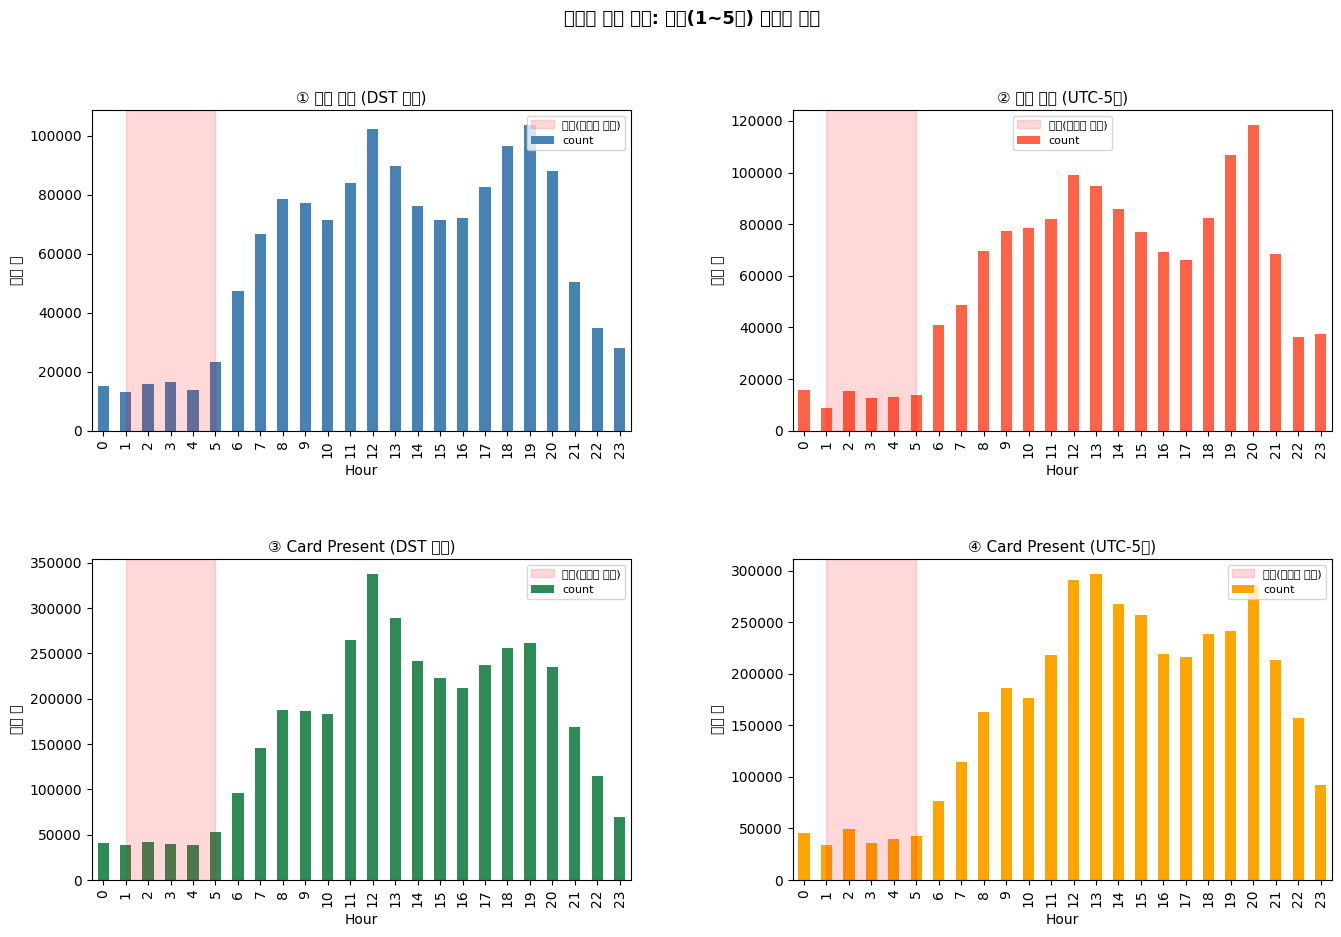

In [95]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

CHAINS  = ['MCDONALD', 'STARBUCKS', 'SUBWAY', 'BURGER KING', 'WENDY']
chain_mask = df['MERCHANT_NAME'].str.contains('|'.join(CHAINS), case=False, na=False)
cp_mask    = df['CARD_PRESENT_INDICATOR'].str.upper().str.contains('Y|YES|PRESENT', na=False)

df_chain = df[chain_mask]
df_cp    = df[cp_mask]

configs = [
    (gs[0,0], df_chain, 'Hour',      '① 대형 체인 (DST 반영)',  'steelblue'),
    (gs[0,1], df_chain, 'Hour_utc5', '② 대형 체인 (UTC-5만)',   'tomato'),
    (gs[1,0], df_cp,    'Hour',      '③ Card Present (DST 반영)','seagreen'),
    (gs[1,1], df_cp,    'Hour_utc5', '④ Card Present (UTC-5만)', 'orange'),
]

for gs_pos, data, hour_col, title, color in configs:
    ax = fig.add_subplot(gs_pos)
    data[hour_col].value_counts().sort_index().plot(kind='bar', ax=ax, color=color)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Hour')
    ax.set_ylabel('거래 수')
    ax.axvspan(1, 5, alpha=0.15, color='red', label='새벽(낮아야 정상)')
    ax.legend(fontsize=8)

plt.suptitle('시간대 변환 검증: 새벽(1~5시) 거래량 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [97]:
# 새벽(1~5시) 비율 수치 비교
for label, hour_col, data in [
    ('① 대형체인 DST반영',   'Hour',      df_chain),
    ('② 대형체인 UTC-5만',   'Hour_utc5', df_chain),
    ('③ CardPresent DST반영','Hour',      df_cp),
    ('④ CardPresent UTC-5만','Hour_utc5', df_cp),
]:
    total      = len(data)
    dawn_mask  = data[hour_col].between(1, 5)
    dawn_count = dawn_mask.sum()
    dawn_ratio = dawn_count / total * 100
    print(f"{label}: 새벽(1~5시) {dawn_count:,}건 / 전체 {total:,}건 = {dawn_ratio:.2f}%")

① 대형체인 DST반영: 새벽(1~5시) 82,646건 / 전체 1,418,995건 = 5.82%
② 대형체인 UTC-5만: 새벽(1~5시) 63,782건 / 전체 1,418,995건 = 4.49%
③ CardPresent DST반영: 새벽(1~5시) 211,306건 / 전체 3,960,049건 = 5.34%
④ CardPresent UTC-5만: 새벽(1~5시) 202,509건 / 전체 3,960,049건 = 5.11%


In [98]:
for label, hour_col, data in [
    ('① 대형체인 DST반영',    'Hour',      df_chain),
    ('② 대형체인 UTC-5만',    'Hour_utc5', df_chain),
    ('③ CardPresent DST반영', 'Hour',      df_cp),
    ('④ CardPresent UTC-5만', 'Hour_utc5', df_cp),
]:
    peak = data[hour_col].value_counts().idxmax()
    top3 = data[hour_col].value_counts().nlargest(3).index.tolist()
    print(f"{label}: 최고 피크 {peak}시, Top3 {top3}")

① 대형체인 DST반영: 최고 피크 19시, Top3 [19, 12, 18]
② 대형체인 UTC-5만: 최고 피크 20시, Top3 [20, 19, 12]
③ CardPresent DST반영: 최고 피크 12시, Top3 [12, 13, 11]
④ CardPresent UTC-5만: 최고 피크 13시, Top3 [13, 12, 20]


C:\Users\yunji\AppData\Local\Temp\ipykernel_18996\374744097.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = df.groupby(['Hour', 'DayOfWeek'])['TRANSACTION_ID'].count().unstack()


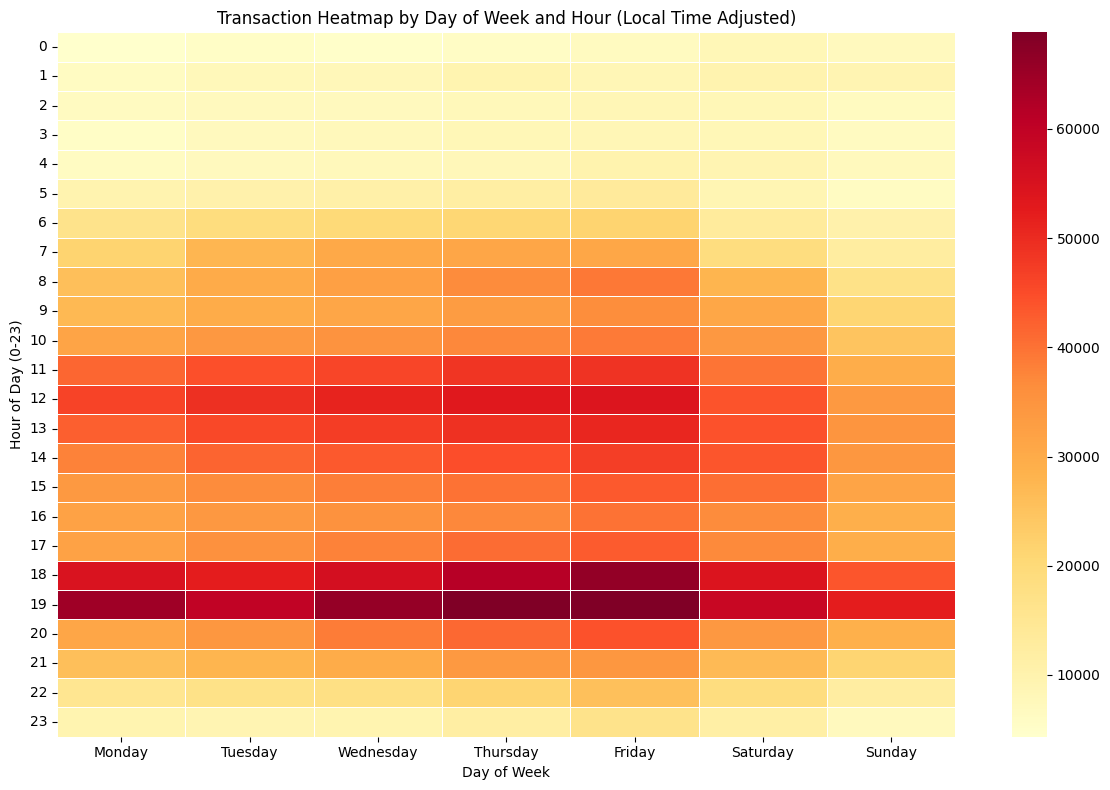

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 타입 변환 (이미 datetime이라면 생략 가능)
df['TRANSACTION_DATE'] = pd.to_datetime(df['TRANSACTION_DATE'])

# 2. 현지 시간대 반영 (미국 동부 EST 기준, UTC-5 적용)
df['LOCAL_TIME'] = df['TRANSACTION_DATE'] - pd.Timedelta(hours=5)

# 3. 요일(Day Name)과 시간(Hour) 변수 파생
df['DayOfWeek'] = df['LOCAL_TIME'].dt.day_name()
df['Hour'] = df['LOCAL_TIME'].dt.hour

# 4. 요일을 월~일 순서대로 정렬하기 위한 카테고리 지정
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['DayOfWeek'] = pd.Categorical(df['DayOfWeek'], categories=days_order, ordered=True)

# 5. 시간(행) x 요일(열) 기준 거래 건수 피벗 테이블 생성
# TRANSACTION_ID의 카운트로 빈도수를 집계합니다.
heatmap_data = df.groupby(['Hour', 'DayOfWeek'])['TRANSACTION_ID'].count().unstack()

# 6. 히트맵 그리기
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False, fmt='.0f', linewidths=.5)

plt.title('Transaction Heatmap by Day of Week and Hour (Local Time Adjusted)')
plt.xlabel('Day of Week')
plt.ylabel('Hour of Day (0-23)')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

C:\Users\yunji\AppData\Local\Temp\ipykernel_18996\877673880.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = gen_df.groupby(['Hour', 'DayOfWeek'])['TRANSACTION_ID'].count().unstack()
C:\Users\yunji\AppData\Local\Temp\ipykernel_18996\877673880.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = gen_df.groupby(['Hour', 'DayOfWeek'])['TRANSACTION_ID'].count().unstack()
C:\Users\yunji\AppData\Local\Temp\ipykernel_18996\877673880.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to reta

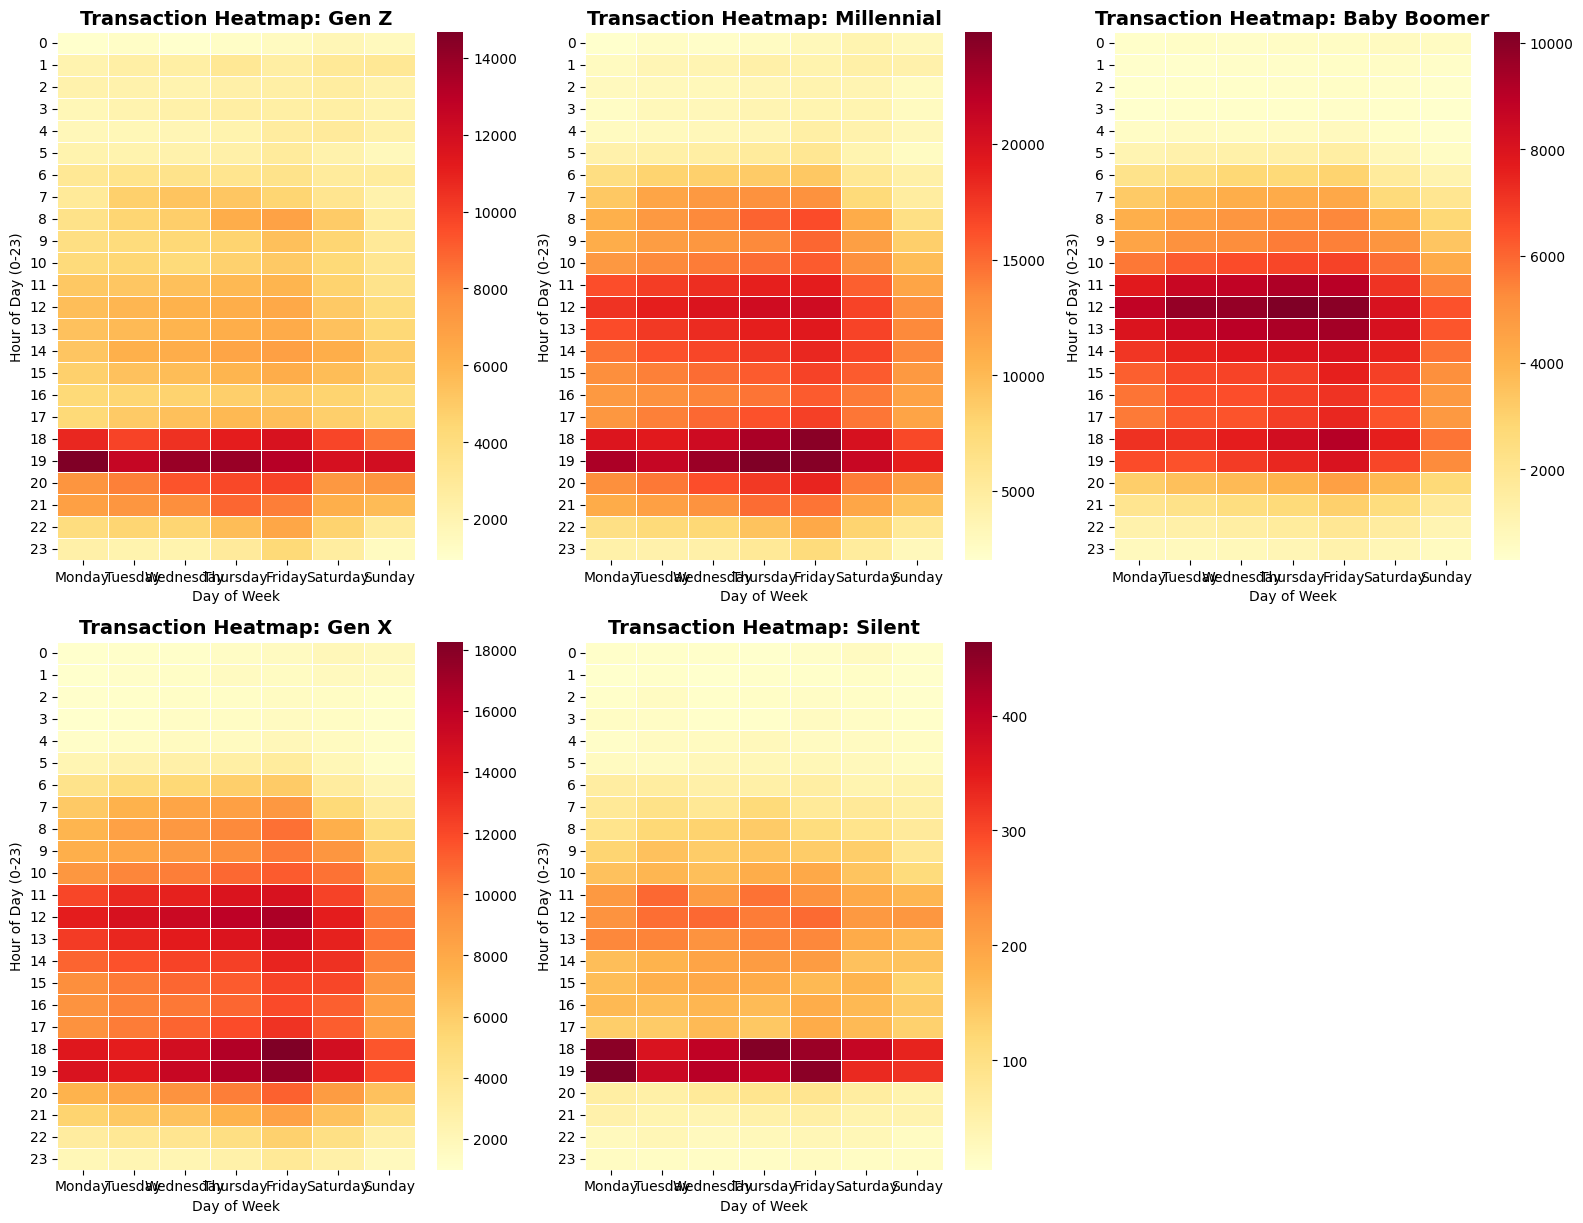

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 세대 목록 추출 (결측치 제외)
generations = df['CARD_HOLDER_GENERATION'].dropna().unique()
# 세대 수에 맞춰 서브플롯(Grid) 크기 설정 (예: 2열로 배치)
cols = 3
rows = (len(generations) + 1) // 2

fig, axes = plt.subplots(rows, cols, figsize=(16, 6 * rows))
axes = axes.flatten() # 1차원 배열로 평탄화하여 반복문 사용 용이하게 함

# 각 세대별로 히트맵 그리기
for i, gen in enumerate(generations):
    # 해당 세대 데이터만 필터링
    gen_df = df[df['CARD_HOLDER_GENERATION'] == gen]
    
    # 시간 x 요일 피벗 테이블 생성
    heatmap_data = gen_df.groupby(['Hour', 'DayOfWeek'])['TRANSACTION_ID'].count().unstack()
    
    # 히트맵 시각화
    # 각 세대별 데이터 모수가 다르므로 절대적인 색상 비교보다는 패턴 비교에 집중합니다.
    sns.heatmap(heatmap_data, cmap='YlOrRd', ax=axes[i], annot=False, linewidths=.5)
    
    axes[i].set_title(f'Transaction Heatmap: {gen}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Day of Week')
    axes[i].set_ylabel('Hour of Day (0-23)')
    axes[i].tick_params(axis='x', rotation=0)

# 남는 빈 그래프 공간 숨기기
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

C:\Users\yunji\AppData\Local\Temp\ipykernel_18996\4101288787.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = ind_df.groupby(['Hour', 'DayOfWeek'])['TRANSACTION_ID'].count().unstack()
C:\Users\yunji\AppData\Local\Temp\ipykernel_18996\4101288787.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = ind_df.groupby(['Hour', 'DayOfWeek'])['TRANSACTION_ID'].count().unstack()
C:\Users\yunji\AppData\Local\Temp\ipykernel_18996\4101288787.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to r

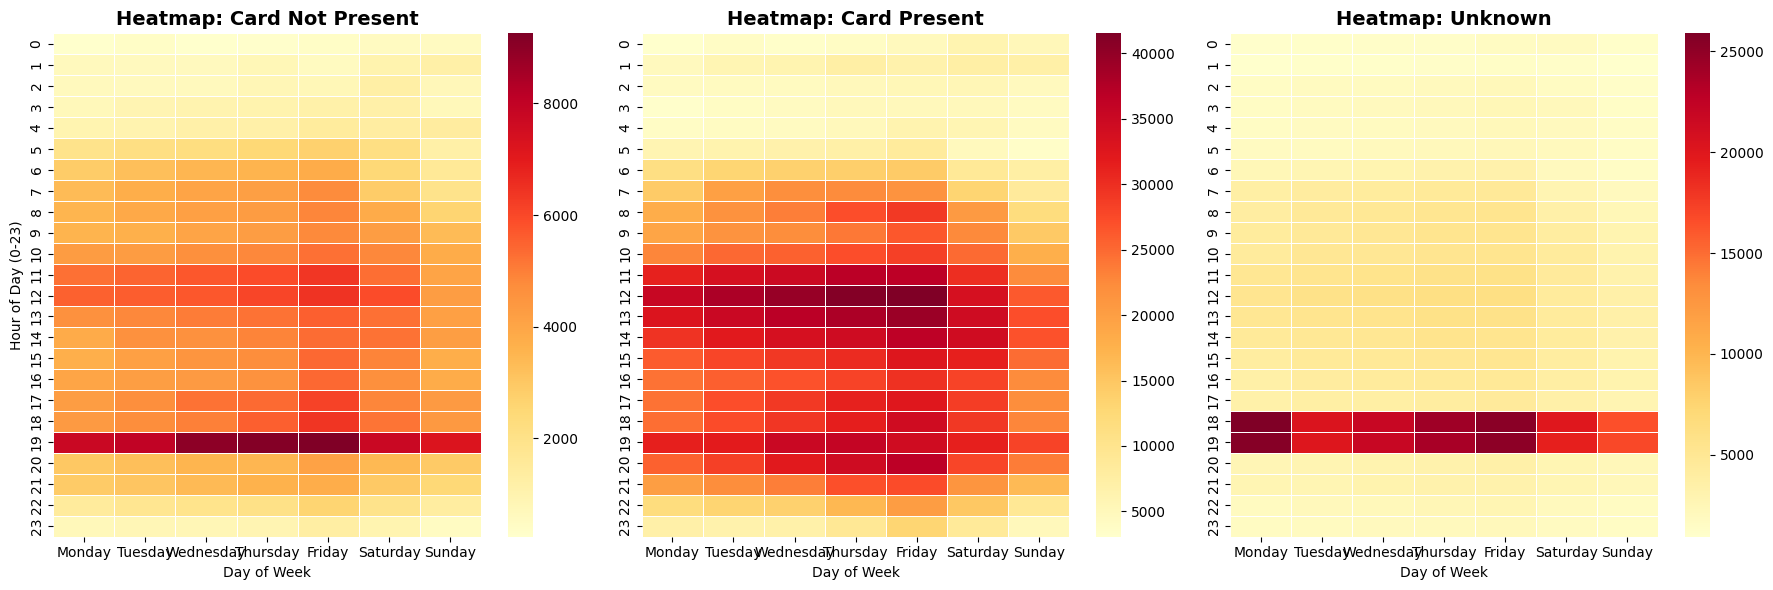

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# CARD_PRESENT_INDICATOR의 고유값 추출 (결측치 제외)
indicators = df['CARD_PRESENT_INDICATOR'].dropna().unique()

# 1행 3열의 서브플롯 생성 (가로로 길게 배치)
fig, axes = plt.subplots(1, len(indicators), figsize=(18, 6))

for i, indicator in enumerate(indicators):
    # 해당 결제 방식 데이터만 필터링
    ind_df = df[df['CARD_PRESENT_INDICATOR'] == indicator]
    
    # 시간 x 요일 피벗 테이블 생성
    heatmap_data = ind_df.groupby(['Hour', 'DayOfWeek'])['TRANSACTION_ID'].count().unstack()
    
    # 히트맵 시각화
    sns.heatmap(heatmap_data, cmap='YlOrRd', ax=axes[i], annot=False, linewidths=.5)
    
    axes[i].set_title(f'Heatmap: {indicator}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Day of Week')
    
    # 첫 번째 그래프에만 y축 라벨(시간) 표시하여 깔끔하게 정리
    if i == 0:
        axes[i].set_ylabel('Hour of Day (0-23)')
    else:
        axes[i].set_ylabel('')
        
    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

C:\Users\yunji\AppData\Local\Temp\ipykernel_18996\4255098657.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data_all = df.groupby(['Hour', 'DayOfWeek'])['TRANSACTION_ID'].count().unstack()


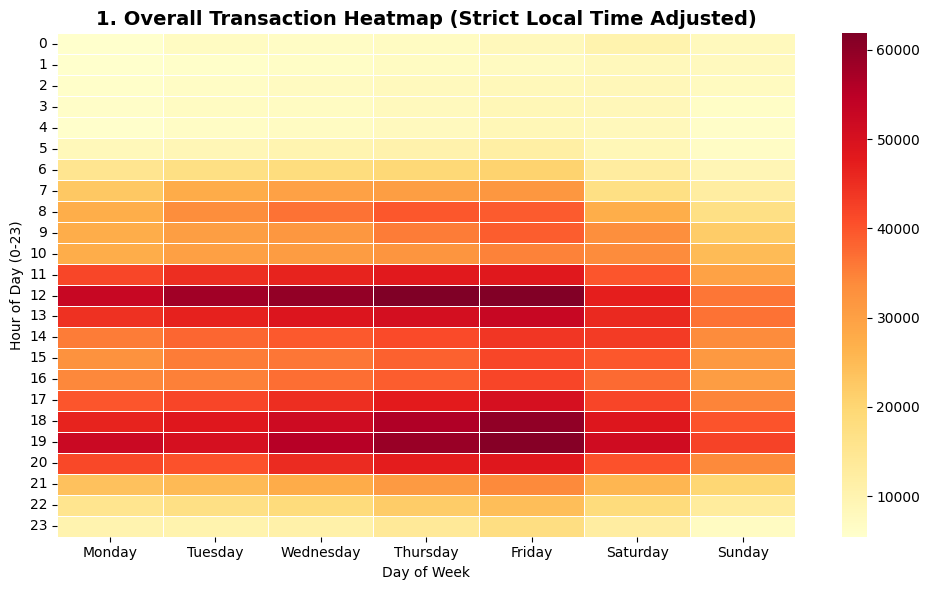

C:\Users\yunji\AppData\Local\Temp\ipykernel_18996\4255098657.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data_gen = gen_df.groupby(['Hour', 'DayOfWeek'])['TRANSACTION_ID'].count().unstack()
C:\Users\yunji\AppData\Local\Temp\ipykernel_18996\4255098657.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data_gen = gen_df.groupby(['Hour', 'DayOfWeek'])['TRANSACTION_ID'].count().unstack()
C:\Users\yunji\AppData\Local\Temp\ipykernel_18996\4255098657.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=Fa

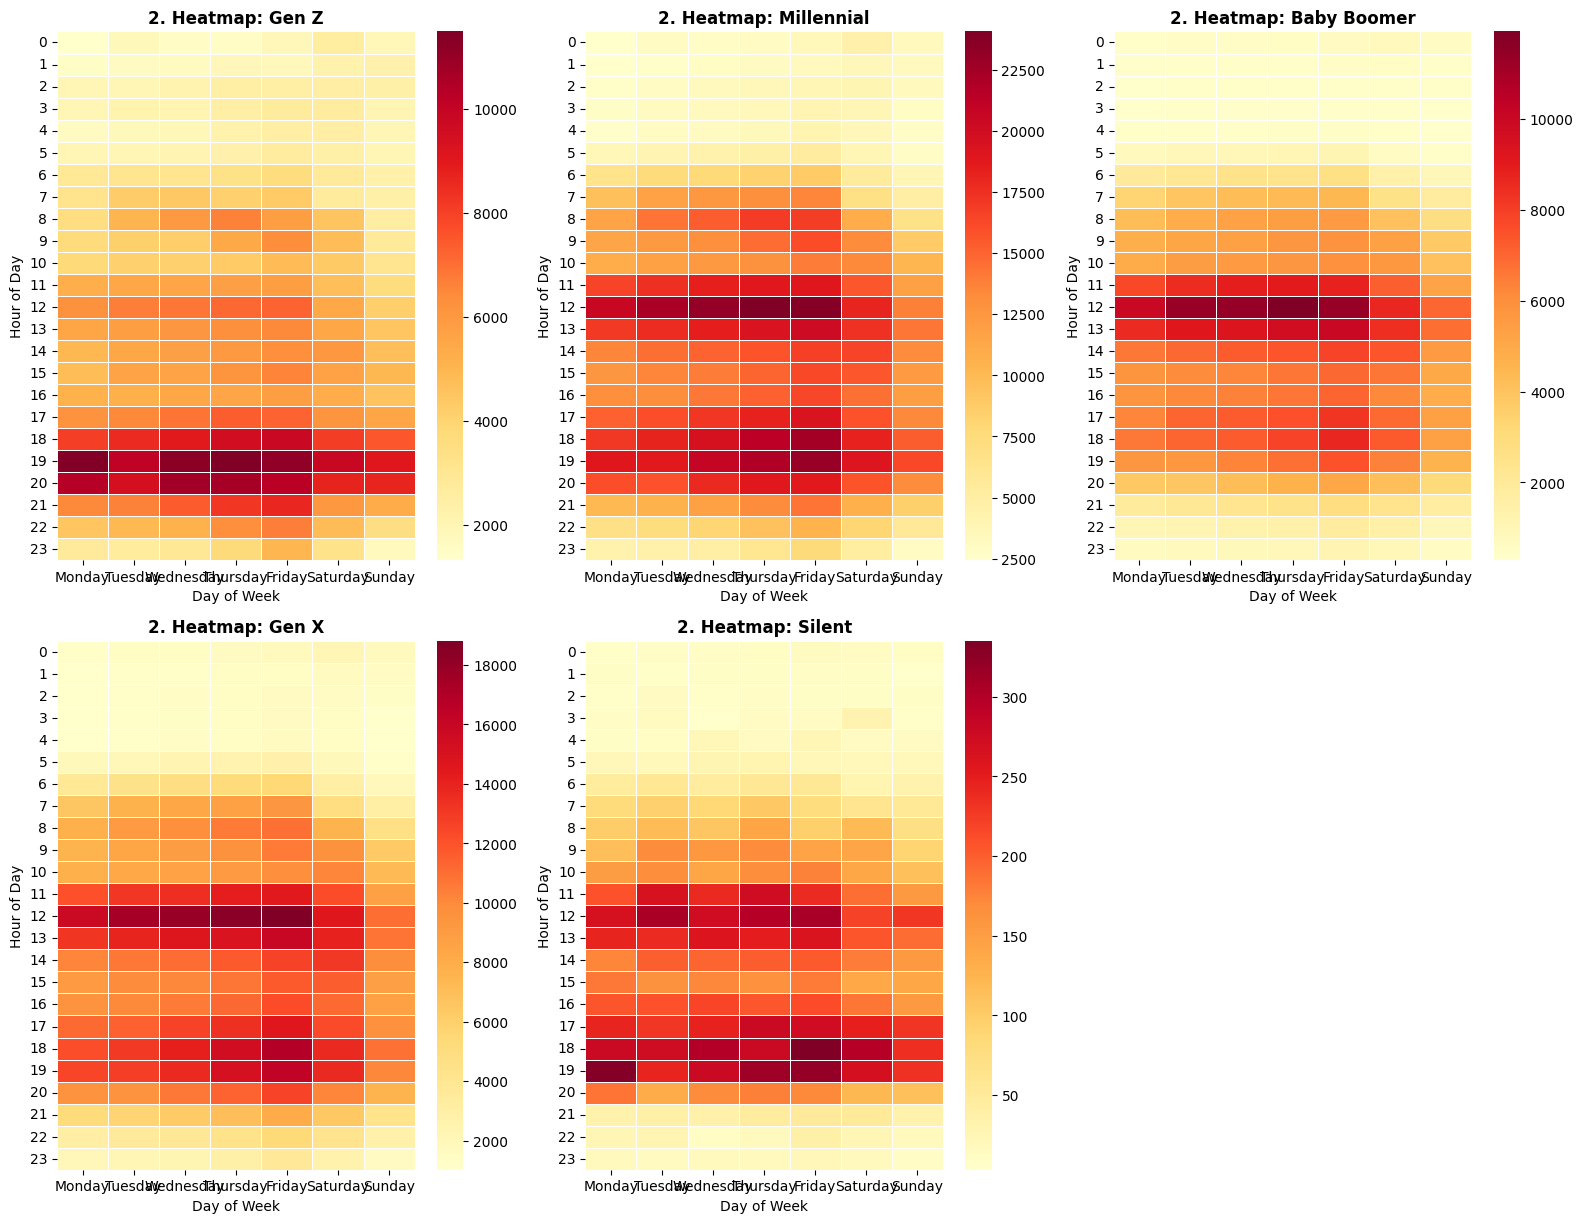

C:\Users\yunji\AppData\Local\Temp\ipykernel_18996\4255098657.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data_ind = ind_df.groupby(['Hour', 'DayOfWeek'])['TRANSACTION_ID'].count().unstack()
C:\Users\yunji\AppData\Local\Temp\ipykernel_18996\4255098657.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data_ind = ind_df.groupby(['Hour', 'DayOfWeek'])['TRANSACTION_ID'].count().unstack()
C:\Users\yunji\AppData\Local\Temp\ipykernel_18996\4255098657.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=Fa

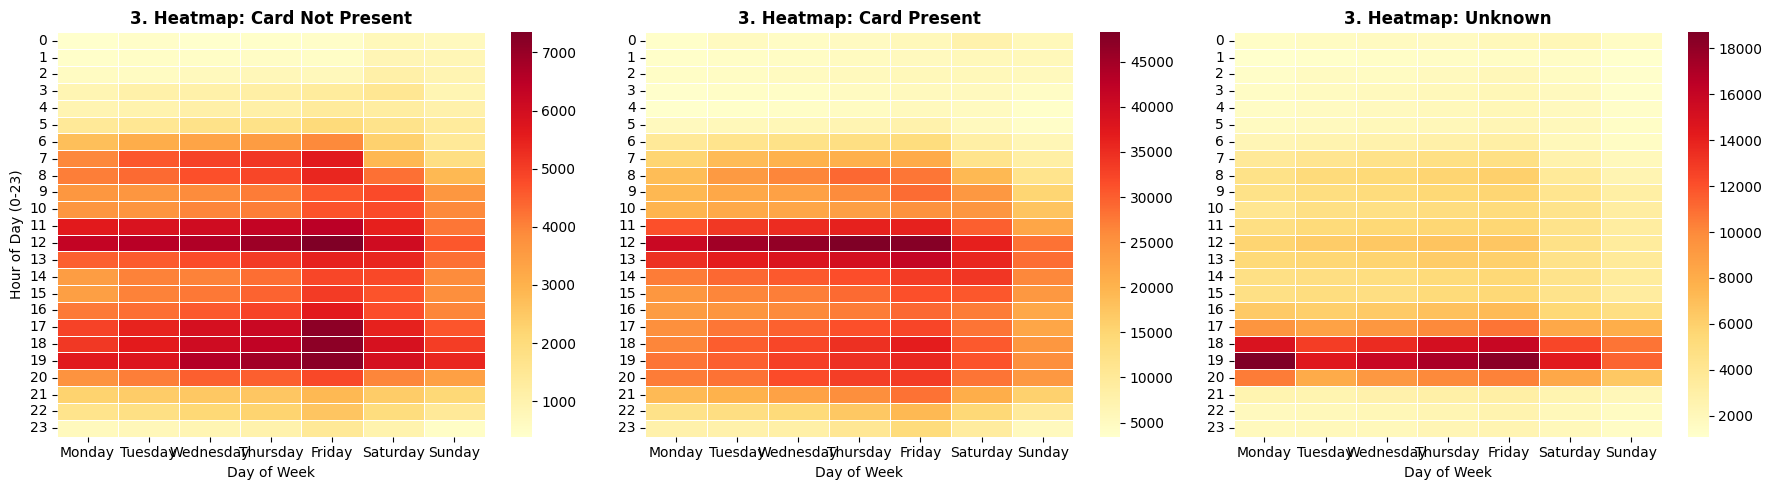

In [84]:
# ==========================================
# 1. 전체 단순 히트맵 (Overall Heatmap)
# ==========================================
plt.figure(figsize=(10, 6))
heatmap_data_all = df.groupby(['Hour', 'DayOfWeek'])['TRANSACTION_ID'].count().unstack()
sns.heatmap(heatmap_data_all, cmap='YlOrRd', annot=False, linewidths=.5)
plt.title('1. Overall Transaction Heatmap (Strict Local Time Adjusted)', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Hour of Day (0-23)')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ==========================================
# 2. 세대별 히트맵 (By Generation)
# ==========================================
generations = df['CARD_HOLDER_GENERATION'].dropna().unique()
cols = 3
rows = (len(generations) + 1) // 2
fig, axes = plt.subplots(rows, cols, figsize=(16, 6 * rows))
axes = axes.flatten()

for i, gen in enumerate(generations):
    gen_df = df[df['CARD_HOLDER_GENERATION'] == gen]
    heatmap_data_gen = gen_df.groupby(['Hour', 'DayOfWeek'])['TRANSACTION_ID'].count().unstack()
    sns.heatmap(heatmap_data_gen, cmap='YlOrRd', ax=axes[i], annot=False, linewidths=.5)
    axes[i].set_title(f'2. Heatmap: {gen}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Day of Week')
    axes[i].set_ylabel('Hour of Day')
    axes[i].tick_params(axis='x', rotation=0)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

# ==========================================
# 3. 결제 방식별 히트맵 (By Card Present Indicator)
# ==========================================
indicators = df['CARD_PRESENT_INDICATOR'].dropna().unique()
fig, axes = plt.subplots(1, len(indicators), figsize=(18, 5))

for i, indicator in enumerate(indicators):
    ind_df = df[df['CARD_PRESENT_INDICATOR'] == indicator]
    heatmap_data_ind = ind_df.groupby(['Hour', 'DayOfWeek'])['TRANSACTION_ID'].count().unstack()
    sns.heatmap(heatmap_data_ind, cmap='YlOrRd', ax=axes[i], annot=False, linewidths=.5)
    axes[i].set_title(f'3. Heatmap: {indicator}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Day of Week')
    if i == 0:
        axes[i].set_ylabel('Hour of Day (0-23)')
    else:
        axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [8]:
import pandas as pd

# 결제 방식(Present)과 카드 타입(Type) 교차표 생성
unknown_mystery_df = df.groupby(['CARD_PRESENT_INDICATOR', 'CARD_TYPE'])['TRANSACTION_ID'].count().unstack().fillna(0)

# 보기 편하게 정수형으로 변환
unknown_mystery_df = unknown_mystery_df.astype(int)

unknown_mystery_df

CARD_TYPE,Benefit - Health,Credit,Debit,General Purpose,Payroll
CARD_PRESENT_INDICATOR,,,,,
Card Not Present,2,169102,408824,315,0
Card Present,83,759409,2619385,2729,200
Unknown,0,63540,644691,40503,62757


In [41]:
# 1. 우리가 쫓는 타겟 데이터만 필터링 (Debit 이면서 Unknown 인 64만 건)
target_df = df[ (df['CARD_PRESENT_INDICATOR'] == 'Unknown')]

# ---------------------------------------------------------
# 단서 1: '시간대'를 확인하자 (과연 얘네들도 18시 배치 처리일까?)
# ---------------------------------------------------------
print("🕒 [단서 1] 시간대별 결제 건수 (상위 5개 시간대)")
print(target_df['Hour'].value_counts().head())

# ---------------------------------------------------------
# 단서 2: '어느 브랜드'에서 발생했는가? (특정 앱이나 가맹점의 문제일까?)
# ---------------------------------------------------------
print("\n🏪 [단서 2] 가맹점(MERCHANT_NAME)별 결제 건수 TOP 10")
print(target_df['MERCHANT_NAME'].value_counts().head(10))

# ---------------------------------------------------------
# 단서 3: '누가' 결제했는가? (Gen Z의 간편결제일까?)
# ---------------------------------------------------------
print("\n🧑‍🤝‍🧑 [단서 3] 세대(GENERATION)별 결제 건수")
# 결측치(NaN)도 포함해서 출력 (익명 결제인지 확인하기 위함)
print(target_df['CARD_HOLDER_GENERATION'].value_counts(dropna=False))

🕒 [단서 1] 시간대별 결제 건수 (상위 5개 시간대)
Hour
18    154264
19    152825
12     37123
13     35578
11     35314
Name: count, dtype: int64

🏪 [단서 2] 가맹점(MERCHANT_NAME)별 결제 건수 TOP 10
MERCHANT_NAME
NO ENTITY              203498
MCDONALDS              115812
STARBUCKS               64835
365 RETAIL MARKETS      50214
CHICK-FIL-A             31980
USA CANTEEN VENDING     24943
DUNKIN DONUTS           22847
TACO BELL               22770
DOMINOS                 18651
BURGER KING             15326
Name: count, dtype: int64

🧑‍🤝‍🧑 [단서 3] 세대(GENERATION)별 결제 건수
CARD_HOLDER_GENERATION
Millennial     318398
Gen X          202695
Gen Z          174284
Baby Boomer     78251
NaN             32595
Silent           5268
Name: count, dtype: int64


In [54]:
# 18시만 필터링
target_df[target_df['Hour'] == 13]['MERCHANT_NAME'].value_counts().head(10)

MERCHANT_NAME
NO ENTITY              9304
MCDONALDS              4547
STARBUCKS              3445
365 RETAIL MARKETS     2720
CHICK-FIL-A            1637
USA CANTEEN VENDING    1540
TACO BELL               893
CHIPOTLE                839
SUBWAY                  642
AVANTI MARKETS          595
Name: count, dtype: int64

In [57]:
df[df['TRANSACTION_DESCRIPTION'] == '000000000000000']

,ACCOUNT_ID,CARD_ID,TRANSACTION_ID,GROSS_TRANSACTION_AMOUNT,TRANSACTION_DATE,TRANSACTION_TYPE,TRANSACTION_STATE,TRANSACTION_CITY,MERCHANT_STATE,MERCHANT_CITY,...,CARD_HOLDER_AVERAGE_LTM_TRANSACTION_COUNT,CARD_HOLDER_VINTAGE,CARD_PRESENT_INDICATOR,MERCHANT_ID,MERCHANT_NAME,SHOPPER_CLASSIFICATION,TZ_NAME,LOCAL_TIME,Hour,DayOfWeek
2751,A9736162,C1587007,T4916257,9.83,2024-06-05 23:51:27+00:00,Spend,TN,FINLEY,NaN,NaN,...,108.25,61,Unknown,0,NO ENTITY,0,America/Chicago,2024-06-05 18:51:27+00:00,18,Wednesday
4959,A1792049,C2486867,T6111116,8.46,2024-04-02 23:46:13+00:00,Spend,TN,JACKSON,NaN,NaN,...,62.33,61,Unknown,0,NO ENTITY,0,America/Chicago,2024-04-02 18:46:13+00:00,18,Tuesday
6307,A4159296,C8359831,T5985095,1.43,2024-06-15 00:02:04+00:00,Spend,TN,DYERSBURG,NaN,NaN,...,69.08,61,Unknown,0,NO ENTITY,0,America/Chicago,2024-06-14 19:02:04+00:00,19,Friday
6336,A9253076,C3783293,T2922103,1.37,2024-01-09 00:05:59+00:00,Spend,PA,YORK,NaN,NaN,...,91.00,4,Unknown,0,NO ENTITY,0,America/New_York,2024-01-08 19:05:59+00:00,19,Monday
8257,A5916341,C7358770,T1194161,4.38,2024-03-28 00:02:53+00:00,Spend,TN,FINLEY,NaN,NaN,...,130.42,61,Unknown,0,NO ENTITY,0,America/Chicago,2024-03-27 19:02:53+00:00,19,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4759508,A3512568,C4862673,T9214684,7.46,2024-01-30 00:06:22+00:00,Spend,TN,RIPLEY,NaN,NaN,...,158.42,61,Unknown,0,NO ENTITY,0,America/Chicago,2024-01-29 19:06:22+00:00,19,Monday
4759649,A9795199,C1330707,T7694879,5.25,2024-02-02 23:54:57+00:00,Spend,TN,NEWBERN,NaN,NaN,...,85.08,61,Unknown,0,NO ENTITY,0,America/Chicago,2024-02-02 18:54:57+00:00,18,Friday
4760889,A6414004,C5429951,T6849460,15.47,2024-06-07 23:50:50+00:00,Spend,TN,UNION CITY,NaN,NaN,...,17.75,61,Unknown,0,NO ENTITY,0,America/Chicago,2024-06-07 18:50:50+00:00,18,Friday
4764399,A2789196,C2235476,T8885650,3.04,2024-05-11 00:08:39+00:00,Spend,TN,UNION CITY,NaN,NaN,...,52.50,61,Unknown,0,NO ENTITY,0,America/Chicago,2024-05-10 19:08:39+00:00,19,Friday


In [56]:
target_df[
    (target_df['Hour'] == 18) & 
    (target_df['MERCHANT_NAME'] == 'NO ENTITY')
]['TRANSACTION_DESCRIPTION'].value_counts().head(20)

TRANSACTION_DESCRIPTION
000000000000000                1357
JACKSONVILLE NC                 782
TAMPA         FL                598
SQUARE PURCHASE                 371
PEPSI BOTTLING VENTUR           326
365 Market  888 432-329         287
Store                           286
PREMIER FOOD SER                247
""""""JACKSONVILLE NC""""""     226
CSC Servicework                 203
CSC SERVICEWORK                 185
DAIRY QUEE DAIRY QUEE           153
844026101882                    152
VEND 1800-766-8728              149
SWANSBORO NC                    128
WILMINGTON NC                   123
RICHLANDS NC                    122
CONTINENTAL SERVICE             109
ALISON VENDING                  108
Continental Service             102
Name: count, dtype: int64

In [39]:
# Unknown 거래의 업종 분포
df[df['CARD_PRESENT_INDICATOR'] == 'Unknown'] \
  .groupby(['MERCHANT_CATEGORY_LEVEL_3']) \
  .size().sort_values(ascending=False).head(40)

MERCHANT_CATEGORY_LEVEL_3
QSR Burgers                      188072
Vending & Beverage Retailers     166779
Coffee / Tea                      84430
QSR Chicken                       62096
Mexican Restaurants               44364
Pizza Restaurants                 40117
QSR Sandwiches                    37089
Breakfast Restaurants             25582
Dessert                           20126
American Restaurants              19857
Payment Services                  16587
Food Services                     13536
General Retail                    10943
Asian Restaurants                  7489
Grocery                            4968
QSR Smoothies                      4948
Military Retailers                 3555
Food Delivery                      2888
Business Services                  1306
Seafood Restaurants                1047
Amusement Parks                    1041
QSR Healthy                         873
Gas / Convenience                   324
Home Furnishing Retailers           324
Nutrition & Vi

In [28]:
df[df['CARD_PRESENT_INDICATOR'] == 'Unknown']['MERCHANT_NAME'].value_counts().head(30)

MERCHANT_NAME
NO ENTITY                              203498
MCDONALDS                              115812
STARBUCKS                               64835
365 RETAIL MARKETS                      50214
CHICK-FIL-A                             31980
USA CANTEEN VENDING                     24943
DUNKIN DONUTS                           22847
TACO BELL                               22770
DOMINOS                                 18651
BURGER KING                             15326
WENDYS                                  14432
SONIC DRIVE-IN                          12731
CHIPOTLE                                12626
SUBWAY                                  11563
AVANTI MARKETS                          10793
LITTLE CAESARS                          10400
NAYAX                                    8581
USCONNECT                                7722
CRANE MERCHANDISING SYSTEMS              7563
WHATABURGER                              6434
PANERA BREAD                             6187
PAPA JOHNS          

In [18]:
unknown = df[df['CARD_PRESENT_INDICATOR'] == 'Unknown']

# 같은 시간에 동일 가맹점에서 얼마나 묶여서 나오나?
unknown.groupby(['MERCHANT_ID', 'TRANSACTION_DATE']).size().sort_values(ascending=False).head(20)

MERCHANT_ID  TRANSACTION_DATE         
0            2024-05-16 00:06:38+00:00    5
             2024-06-18 00:06:24+00:00    5
             2024-04-25 00:04:10+00:00    4
             2024-04-06 00:09:54+00:00    4
             2024-03-05 00:06:59+00:00    4
             2024-02-08 23:51:58+00:00    4
             2024-04-04 23:50:27+00:00    4
             2024-01-27 00:14:15+00:00    4
             2024-01-30 00:03:10+00:00    4
             2024-01-29 23:45:34+00:00    4
             2024-01-15 23:51:57+00:00    4
             2024-04-19 23:52:16+00:00    4
             2024-02-27 00:00:44+00:00    4
             2024-06-23 00:05:09+00:00    4
             2024-06-04 00:03:25+00:00    4
             2024-06-15 23:58:48+00:00    4
             2024-03-23 00:05:51+00:00    4
             2024-04-19 00:12:55+00:00    4
             2024-04-05 00:04:36+00:00    4
             2024-06-29 00:03:19+00:00    4
dtype: int64

In [20]:
df[df['CARD_PRESENT_INDICATOR'] == 'Unknown'].groupby(['CARD_TYPE', 'CARD_HOLDER_GENERATION']).size().unstack()

CARD_HOLDER_GENERATION,Baby Boomer,Gen X,Gen Z,Millennial,Silent
CARD_TYPE,,,,,
Credit,12867,15928,5113,29063,537
Debit,58389,161138,144700,249534,4414
General Purpose,3230,11255,6895,15892,172
Payroll,3765,14374,17576,23909,145


In [42]:
# 이걸 확인해야 퍼즐이 진짜 완성됨
df.groupby('CARD_HOLDER_GENERATION')['CARD_PRESENT_INDICATOR'] \
  .value_counts(normalize=True).unstack()

CARD_PRESENT_INDICATOR,Card Not Present,Card Present,Unknown
CARD_HOLDER_GENERATION,,,
Baby Boomer,0.079575,0.807457,0.112968
Gen X,0.103874,0.738241,0.157885
Gen Z,0.130908,0.657239,0.211852
Millennial,0.136856,0.695237,0.167907
Silent,0.061641,0.682470,0.255890


In [74]:
for hour in [12, 13, 18, 19]:
    print(f"\n🕒 {hour}시 NO ENTITY  TOP 10")
    print(
        target_df[
            (target_df['Hour'] == hour) & 
            (target_df['MERCHANT_NAME'] == 'NO ENTITY')
        ]['MERCHANT_CATEGORY_LEVEL_3'].value_counts()
    )


🕒 12시 NO ENTITY  TOP 10
MERCHANT_CATEGORY_LEVEL_3
Vending & Beverage Retailers     4540
Dessert                          1087
Coffee / Tea                      657
General Retail                    516
Food Services                     477
Mexican Restaurants               262
QSR Burgers                       185
QSR Chicken                       176
American Restaurants              149
QSR Sandwiches                    115
Grocery                           114
Asian Restaurants                  96
QSR Healthy                        48
Pizza Restaurants                  44
Nutrition & Vitamin Retailers      21
Military Retailers                 17
Seafood Restaurants                17
Payment Services                   13
Amusement Parks                     9
QSR Smoothies                       5
Food Delivery                       4
Name: count, dtype: int64

🕒 13시 NO ENTITY  TOP 10
MERCHANT_CATEGORY_LEVEL_3
Vending & Beverage Retailers     4374
Dessert                           99

In [68]:
for hour in [12, 13, 18, 19]:
    print(f"\n🕒 {hour}시 TOP 5")
    print(
        target_df[
            (target_df['Hour'] == hour)
        ]['CARD_TYPE'].value_counts().head(5)
    )


🕒 12시 TOP 5
CARD_TYPE
Debit              31067
Credit              5118
Payroll              733
General Purpose      205
Name: count, dtype: int64

🕒 13시 TOP 5
CARD_TYPE
Debit              29576
Credit              5010
Payroll              783
General Purpose      209
Name: count, dtype: int64

🕒 18시 TOP 5
CARD_TYPE
Debit              125519
Payroll             17136
General Purpose      6394
Credit               5215
Name: count, dtype: int64

🕒 19시 TOP 5
CARD_TYPE
Debit              123805
Payroll             17437
General Purpose      6618
Credit               4965
Name: count, dtype: int64


In [ ]:
for hour in [12, 13, 18, 19]:
    print(f"\n🕒 {hour}시 NO ENTITY TRANSACTION_DESCRIPTION TOP 10")
    print(
        df[
            (df['Hour'] == hour) & 
            (df['MERCHANT_NAME'] == 'NO ENTITY')
        ]['CARD_TYPE'].value_counts().head(5)
    )

C:\Users\yunji\AppData\Local\Temp\ipykernel_18996\3186939764.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = ind_df.groupby(['Hour', 'DayOfWeek'])['TRANSACTION_ID'].count().unstack()
C:\Users\yunji\AppData\Local\Temp\ipykernel_18996\3186939764.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = ind_df.groupby(['Hour', 'DayOfWeek'])['TRANSACTION_ID'].count().unstack()
C:\Users\yunji\AppData\Local\Temp\ipykernel_18996\3186939764.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to r

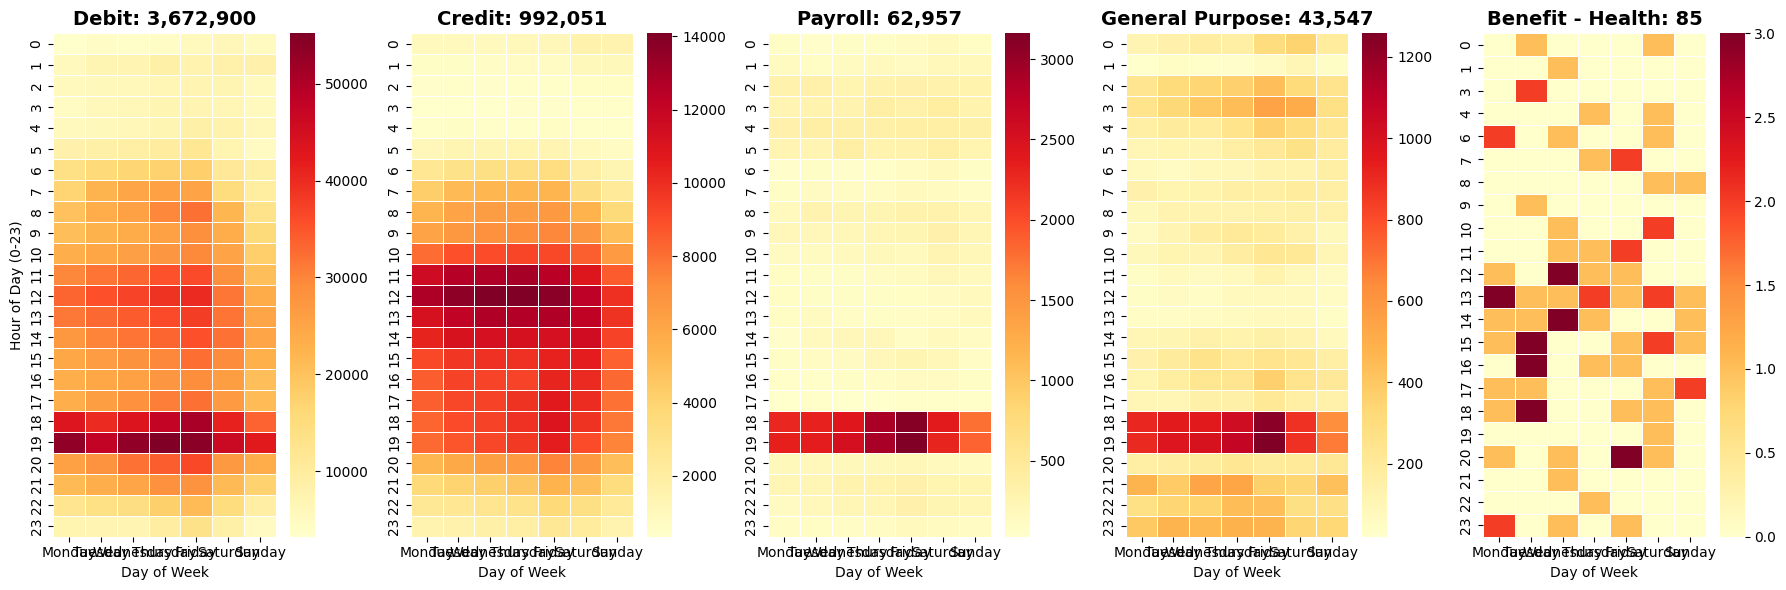

In [76]:
# CARD_PRESENT_INDICATOR의 고유값 추출 (결측치 제외)
indicators = df['CARD_TYPE'].dropna().unique()

# 1행 n열의 서브플롯 생성
fig, axes = plt.subplots(1, len(indicators), figsize=(18, 6))

# indicators가 하나일 경우 axes가 배열이 아닐 수 있으므로 리스트로 변환
if len(indicators) == 1:
    axes = [axes]

for i, indicator in enumerate(indicators):
    # 해당 결제 방식 데이터만 필터링
    ind_df = df[df['CARD_TYPE'] == indicator]
    
    # 해당 카드 타입의 총 거래 건수 계산
    transaction_count = ind_df.shape[0]
    
    # 시간 x 요일 피벗 테이블 생성
    heatmap_data = ind_df.groupby(['Hour', 'DayOfWeek'])['TRANSACTION_ID'].count().unstack()
    
    # 히트맵 시각화
    sns.heatmap(heatmap_data, cmap='YlOrRd', ax=axes[i], annot=False, linewidths=.5)
    
    # 제목 수정: 카드 타입명과 거래 건수 표시 (천 단위 콤마 추가)
    axes[i].set_title(f'{indicator}: {transaction_count:,}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Day of Week')
    
    # 첫 번째 그래프에만 y축 라벨 표시
    if i == 0:
        axes[i].set_ylabel('Hour of Day (0-23)')
    else:
        axes[i].set_ylabel('')
        
    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

C:\Users\yunji\AppData\Local\Temp\ipykernel_18996\1960999885.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = filtered_df.groupby(['Hour', 'DayOfWeek'])['TRANSACTION_ID'].count().unstack()
C:\Users\yunji\AppData\Local\Temp\ipykernel_18996\1960999885.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = filtered_df.groupby(['Hour', 'DayOfWeek'])['TRANSACTION_ID'].count().unstack()
C:\Users\yunji\AppData\Local\Temp\ipykernel_18996\1960999885.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=

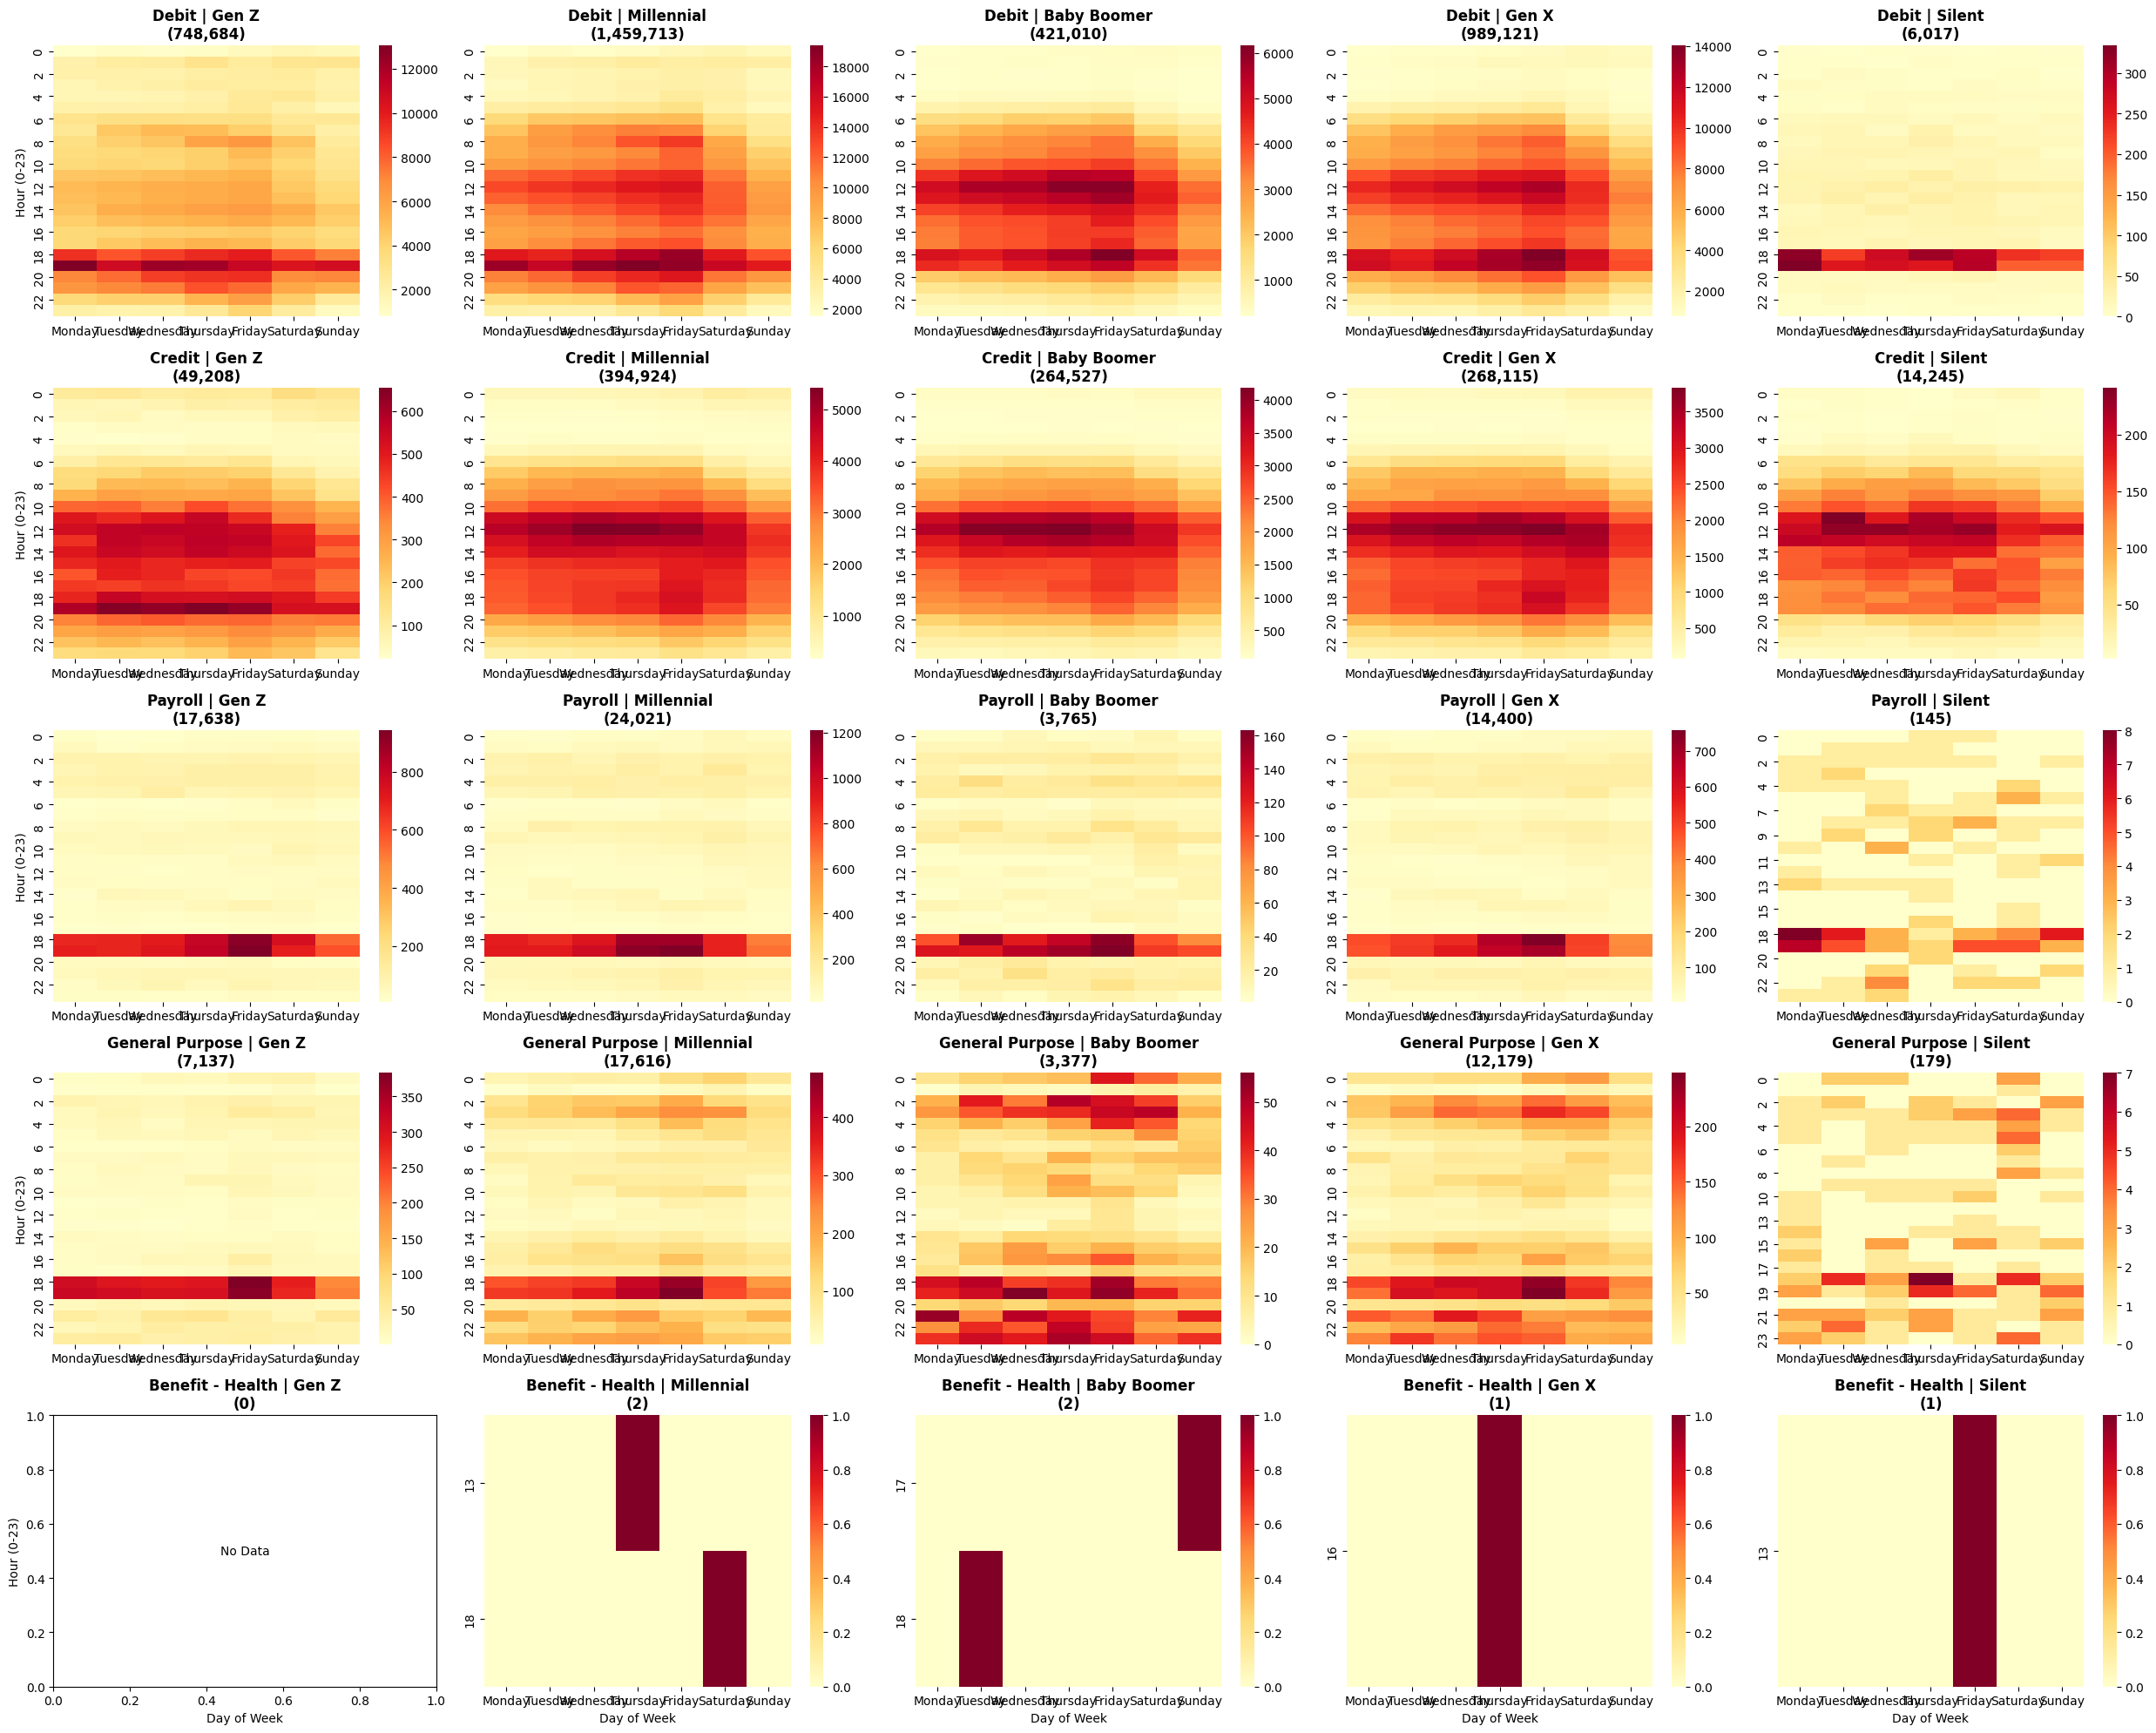

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

# 고유값 추출 (결측치 제외)
card_types = df['CARD_TYPE'].dropna().unique()
generations = df['CARD_HOLDER_GENERATION'].dropna().unique()

# 5행 5열의 서브플롯 생성 (전체 크기를 넉넉하게 잡습니다)
fig, axes = plt.subplots(len(card_types), len(generations), figsize=(25, 20))

for i, card_type in enumerate(card_types):
    for j, gen in enumerate(generations):
        # 해당 카드 타입 + 해당 세대 데이터 필터링
        filtered_df = df[(df['CARD_TYPE'] == card_type) & 
                         (df['CARD_HOLDER_GENERATION'] == gen)]
        
        # 거래 건수 계산
        count = filtered_df.shape[0]
        
        # 데이터가 있는 경우에만 히트맵 생성 (빈 데이터프레임 오류 방지)
        if count > 0:
            # 시간 x 요일 피벗 테이블 생성
            heatmap_data = filtered_df.groupby(['Hour', 'DayOfWeek'])['TRANSACTION_ID'].count().unstack()
            
            # 히트맵 시각화 (컬러바는 너무 많으면 지저분하므로 cbar=False 옵션 고려 가능)
            sns.heatmap(heatmap_data, cmap='YlOrRd', ax=axes[i, j], annot=False, cbar=True)
        else:
            # 데이터가 없는 칸은 빈 상태로 두고 안내 텍스트 표시
            axes[i, j].text(0.5, 0.5, 'No Data', ha='center', va='center')

        # 제목 설정: 카드 타입 - 세대: 건수
        axes[i, j].set_title(f'{card_type} | {gen}\n({count:,})', fontsize=12, fontweight='bold')
        
        # 레이아웃 정리를 위해 축 라벨 제어
        if i == len(card_types) - 1:
            axes[i, j].set_xlabel('Day of Week')
        else:
            axes[i, j].set_xlabel('')
            
        if j == 0:
            axes[i, j].set_ylabel('Hour (0-23)')
        else:
            axes[i, j].set_ylabel('')

        axes[i, j].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()